In [1]:
import kagglehub
msambare_fer2013_path = kagglehub.dataset_download('msambare/fer2013')

print('Data source import complete.')


Using Colab cache for faster access to the 'fer2013' dataset.
Data source import complete.


In [2]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.layers import Conv2D, Dense, BatchNormalization, Activation, Dropout, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, TensorBoard, EarlyStopping, ReduceLROnPlateau
import datetime
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model

In [3]:
import os # Ensure os is imported for os.path.join

train_dir = '/kaggle/input/fer2013/train'
test_dir = '/kaggle/input/fer2013/test'

row, col = 48, 48
classes = 7

def count_exp(path, set_):
    dict_ = {}
    for expression in os.listdir(path):
        dir_ = os.path.join(path, expression) # Corrected path construction
        dict_[expression] = len(os.listdir(dir_))
    df = pd.DataFrame(dict_, index=[set_])
    return df
train_count = count_exp(train_dir, 'train')
test_count = count_exp(test_dir, 'test')
print(train_count)
print(test_count)

       surprise  fear  angry  neutral   sad  disgust  happy
train      3171  4097   3995     4965  4830      436   7215
      surprise  fear  angry  neutral   sad  disgust  happy
test       831  1024    958     1233  1247      111   1774


### PLot of number of images in training set

<Axes: >

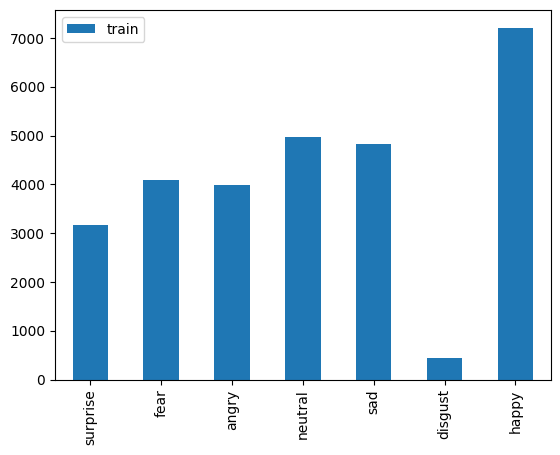

In [4]:
train_count.transpose().plot(kind='bar')

<Axes: >

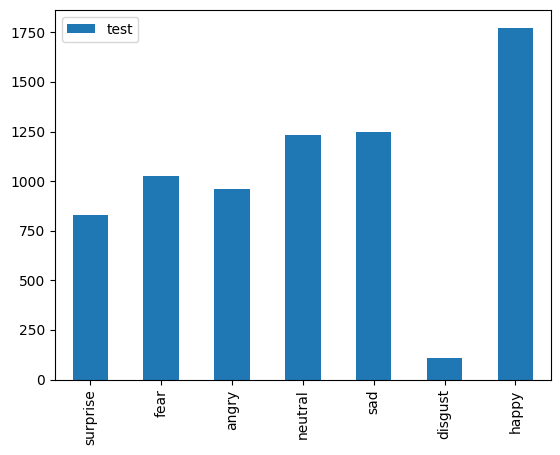

In [5]:
test_count.transpose().plot(kind='bar')

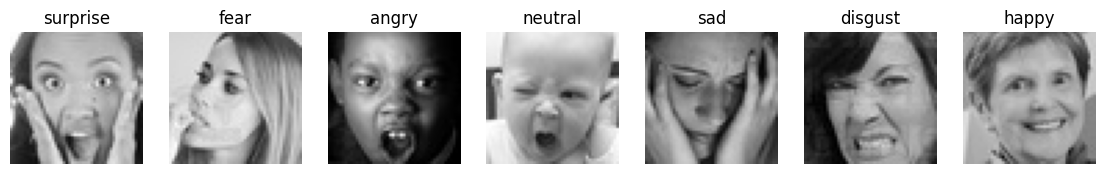

In [6]:
plt.figure(figsize=(14,22))
i = 1
for expression in os.listdir(train_dir):
    # Correctly join path components using os.path.join
    expression_dir = os.path.join(train_dir, expression)
    # Ensure there are files in the directory before trying to access index 5
    if os.listdir(expression_dir):
        img_path = os.path.join(expression_dir, os.listdir(expression_dir)[5])
        img = load_img(img_path)
        plt.subplot(1,7,i)
        plt.imshow(img)
        plt.title(expression)
        plt.axis('off')
        i += 1
plt.show()

## Creating Training and test sets

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   zoom_range=0.3,
                                   horizontal_flip=True)

training_set = train_datagen.flow_from_directory(train_dir,
                                                batch_size=64,
                                                target_size=(48,48),
                                                shuffle=True,
                                                color_mode='grayscale',
                                                class_mode='categorical')

test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory(test_dir,
                                                batch_size=64,
                                                target_size=(48,48),
                                                shuffle=True,
                                                color_mode='grayscale',
                                                class_mode='categorical')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [8]:
training_set.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

## Defining Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def get_model(input_size=(48, 48, 1), classes=7):

    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3,3), activation='relu', padding='same',
                     input_shape=input_size))
    model.add(MaxPooling2D((2,2)))

    # Block 2
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    # Block 3
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    # Fully Connected
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    # Output
    model.add(Dense(classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [10]:
fernet = get_model((row,col,1), classes)
fernet.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

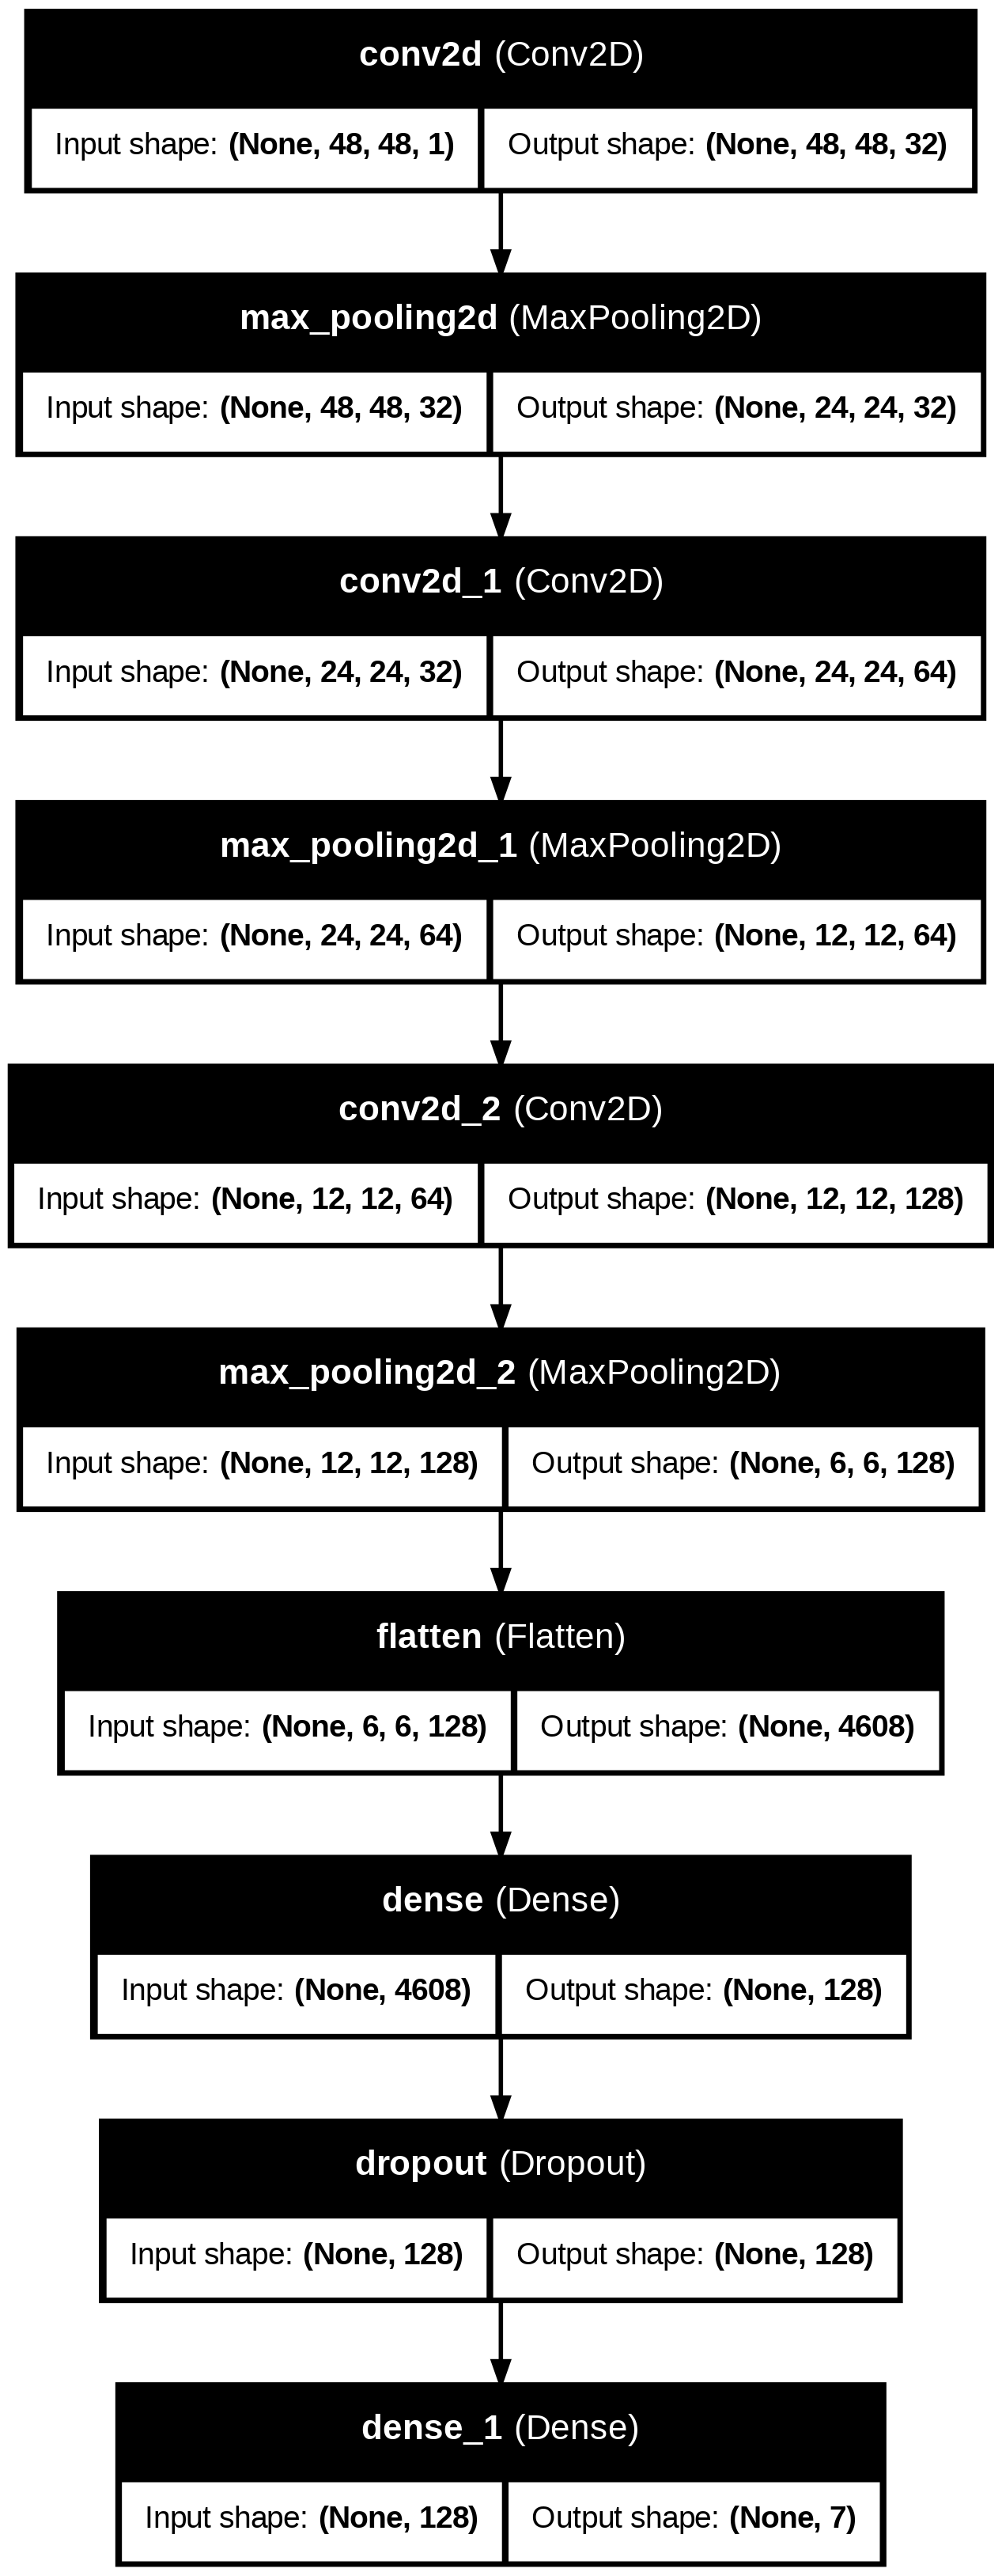

In [11]:
plot_model(fernet, to_file='fernet.png', show_shapes=True, show_layer_names=True)

### Callbacks Function

In [12]:
chk_path = 'ferNet.h5'
log_dir = "checkpoint/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

checkpoint = ModelCheckpoint(filepath=chk_path,
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             monitor='val_loss')

earlystop = EarlyStopping(monitor='val_loss',
                          min_delta=0,
                          patience=3,
                          verbose=1,
                          restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=6,
                              verbose=1,
                              min_delta=0.0001)


tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
csv_logger = CSVLogger('training.log')

callbacks = [checkpoint, reduce_lr, csv_logger]

## Training Model

In [ ]:
steps_per_epoch = training_set.n // training_set.batch_size
validation_steps = test_set.n // test_set.batch_size

hist = fernet.fit(x=training_set,
                 validation_data=test_set,
                 epochs=500,
                 callbacks=callbacks,
                 steps_per_epoch=steps_per_epoch,
                 validation_steps=validation_steps)

Epoch 1/500
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5894 - loss: 1.0903
Epoch 1: val_loss did not improve from 1.05646
448/448 ━━━━━━━━━━━━━━━━━━━━ 49s 97ms/step - accuracy: 0.5826 - loss: 1.1084 - val_accuracy: 0.5918 - val_loss: 1.0842 - learning_rate: 0.0010
Epoch 2/500
  1/448 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5312 - loss: 1.2232

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 1.05646
448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5312 - loss: 1.2232 - val_accuracy: 0.5894 - val_loss: 1.0855 - learning_rate: 0.0010
Epoch 3/500
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5800 - loss: 1.1091
Epoch 3: val_loss did not improve from 1.05646
448/448 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.5807 - loss: 1.1062 - val_accuracy: 0.5921 - val_loss: 1.0811 - learning_rate: 0.0010
Epoch 4/500
  1/448 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5938 - loss: 0.9638
Epoch 4: val_loss did not improve from 1.05646
448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5938 - loss: 0.9638 - val_accuracy: 0.5928 - val_loss: 1.0843 - learning_rate: 0.0010
Epoch 5/500
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5805 - loss: 1.1081
Epoch 5: val_loss did not improve from 1.05646
448/448 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.5840 - loss: 1.1036 - val_accuracy: 0.5880 - val_loss: 1.0933 -

## Loss and Accuracy plot

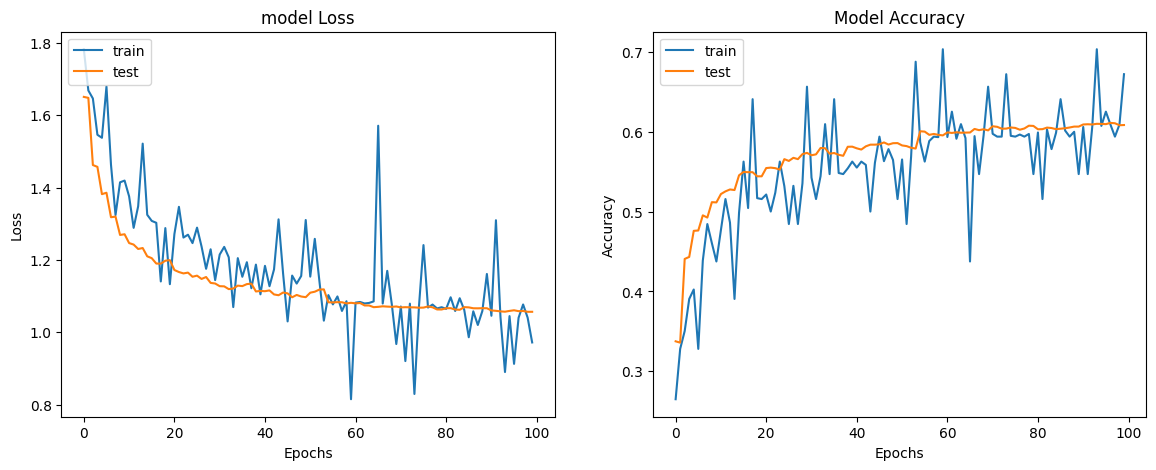

In [14]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'], loc='upper left')

plt.subplot(1,2,1)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step


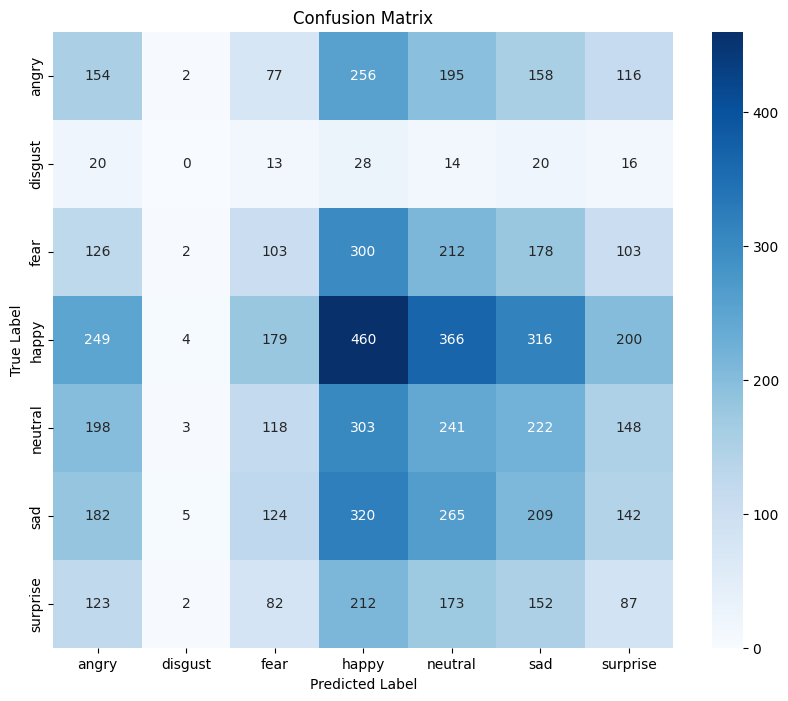

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Reset the test_set generator to ensure predictions are made from the start
test_set.reset()

# Get true labels
y_true = test_set.classes

# Get predictions from the model
# Predict probabilities for each class
y_pred_probabilities = fernet.predict(test_set, steps=len(test_set), verbose=1)
# Convert probabilities to predicted class indices
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Generate the confusion matrix
conf_mat = confusion_matrix(y_true, y_pred)

# Get class names from the training_set.class_indices, sorted by index
class_names = [k for k, v in sorted(training_set.class_indices.items(), key=lambda item: item[1])]

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Model evaluation

In [15]:
train_loss, train_accu = fernet.evaluate(training_set)
test_loss, test_accu = fernet.evaluate(test_set)
print("final train accuracy = {:.2f} , validation accuracy = {:.2f}".format(train_accu*100, test_accu*100))

449/449 ━━━━━━━━━━━━━━━━━━━━ 36s 80ms/step - accuracy: 0.6390 - loss: 0.9578
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.6082 - loss: 1.0564
final train accuracy = 63.90 , validation accuracy = 60.82


In [16]:
fernet.save_weights('fernet_bestweight.weights.h5')

In [17]:
fernet.save("fer_model.keras")

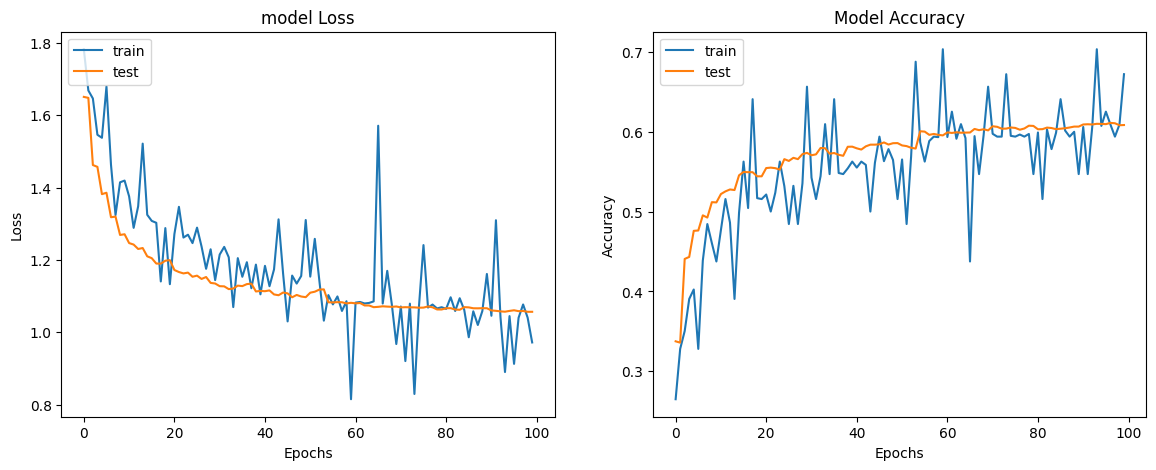

In [18]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'], loc='upper left')

plt.subplot(1,2,1)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## 6. Final Accuracy

Below are the final training and validation accuracies.

In [19]:
train_loss, train_accu = fernet.evaluate(training_set)
test_loss, test_accu = fernet.evaluate(test_set)
print(f"Final training accuracy = {train_accu*100:.2f} ")
print(f"Final validation accuracy = {test_accu*100:.2f}")

449/449 ━━━━━━━━━━━━━━━━━━━━ 35s 78ms/step - accuracy: 0.6414 - loss: 0.9555
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.6082 - loss: 1.0564
Final training accuracy = 64.14 
Final validation accuracy = 60.82


In [20]:
import gradio as gr
from PIL import Image
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array

# Recreate the model structure
# Assuming get_model function is available from previous cells
fernet = get_model((row,col,1), classes)

# Load the best weights
fernet.load_weights('fernet_bestweight.weights.h5')

# Define the class labels mapping (from training_set.class_indices)
class_labels_map = {v: k for k, v in training_set.class_indices.items()}

# Define the prediction function for Gradio
def predict_emotion(image):
    if image is None:
        return "Please upload an image."

    # Convert PIL Image to numpy array and ensure grayscale
    img_array = img_to_array(image.convert('L'))

    # Resize image to (48, 48)
    img_array = tf.image.resize(img_array, (48, 48)).numpy()

    # Normalize pixel values
    img_array = img_array / 255.0

    # Reshape for model input (batch_size, height, width, channels)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = np.expand_dims(img_array, axis=-1) # Add channel dimension for grayscale

    # Make prediction
    predictions = fernet.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    predicted_emotion = class_labels_map[predicted_class_index]

    return predicted_emotion


# Create Gradio interface
iface = gr.Interface(fn=predict_emotion,
                     inputs=gr.Image(type="pil", label="Upload an Image"),
                     outputs="text",
                     title="Facial Emotion Recognition",
                     description="Upload a facial image to predict the emotion (angry, disgust, fear, happy, neutral, sad, surprise).")

# Launch the interface
iface.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3c115a1d0fdf82081d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://3c115a1d0fdf82081d.gradio.live
